In [ ]:
"""
Module: Advanced_Analytics.py
Description: Performs advanced risk analytics including VaR,
             CVaR, Rolling Sharpe Ratio, Investor Cohort
             Analysis, SIP Continuity, and Fund Recommender.
Author: Nethi Vamshi
Project: Bluestock Fintech - Mutual Fund Analytics Capstone
Date: June 2026
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("data/processed").mkdir(exist_ok=True)
Path("reports/charts").mkdir(parents=True, exist_ok=True)

In [2]:
nav = pd.read_csv("data/raw/02_nav_history.csv")
investor = pd.read_csv("data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
fund = pd.read_csv("data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav.head())
print(investor.head())
print(portfolio.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Fa

In [3]:
def calculate_var_cvar(group):
    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        return pd.Series({
            "VaR_95": np.nan,
            "CVaR_95": np.nan
        })

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar = nav.groupby("amfi_code").apply(calculate_var_cvar).reset_index()

var_cvar = var_cvar.merge(fund, on="amfi_code", how="left")

var_cvar.to_csv("data/processed/var_cvar_report.csv", index=False)

var_cvar.head()

/var/folders/_5/x39y9r2522sgpmc7z5pqdbyh0000gn/T/ipykernel_2316/3436084833.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  var_cvar = nav.groupby("amfi_code").apply(calculate_var_cvar).reset_index()


,amfi_code,VaR_95,CVaR_95,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,-0.014364,-0.018060,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100025,-0.003793,-0.004994,HDFC Mutual Fund,HDFC Short Term Debt Fund - Regular - Growth,Debt,Short Duration,Regular,2002-06-25,CRISIL Short Term Bond Index,0.56,0.5,500,1000,Anil Bamboli,Low,DC02
2,100033,-0.019034,-0.023456,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
3,101206,-0.013282,-0.017439,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
4,101207,-0.026021,-0.032459,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03


In [4]:
risk_free_rate = 0.065

nav["rolling_mean"] = nav.groupby("amfi_code")["daily_return"].transform(
    lambda x: x.rolling(90).mean()
)

nav["rolling_std"] = nav.groupby("amfi_code")["daily_return"].transform(
    lambda x: x.rolling(90).std()
)

nav["rolling_sharpe"] = (
    (nav["rolling_mean"] * 252 - risk_free_rate) /
    (nav["rolling_std"] * np.sqrt(252))
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [5]:
risk_free_rate = 0.065

nav["rolling_mean"] = nav.groupby("amfi_code")["daily_return"].transform(
    lambda x: x.rolling(90).mean()
)

nav["rolling_std"] = nav.groupby("amfi_code")["daily_return"].transform(
    lambda x: x.rolling(90).std()
)

nav["rolling_sharpe"] = (
    (nav["rolling_mean"] * 252 - risk_free_rate) /
    (nav["rolling_std"] * np.sqrt(252))
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


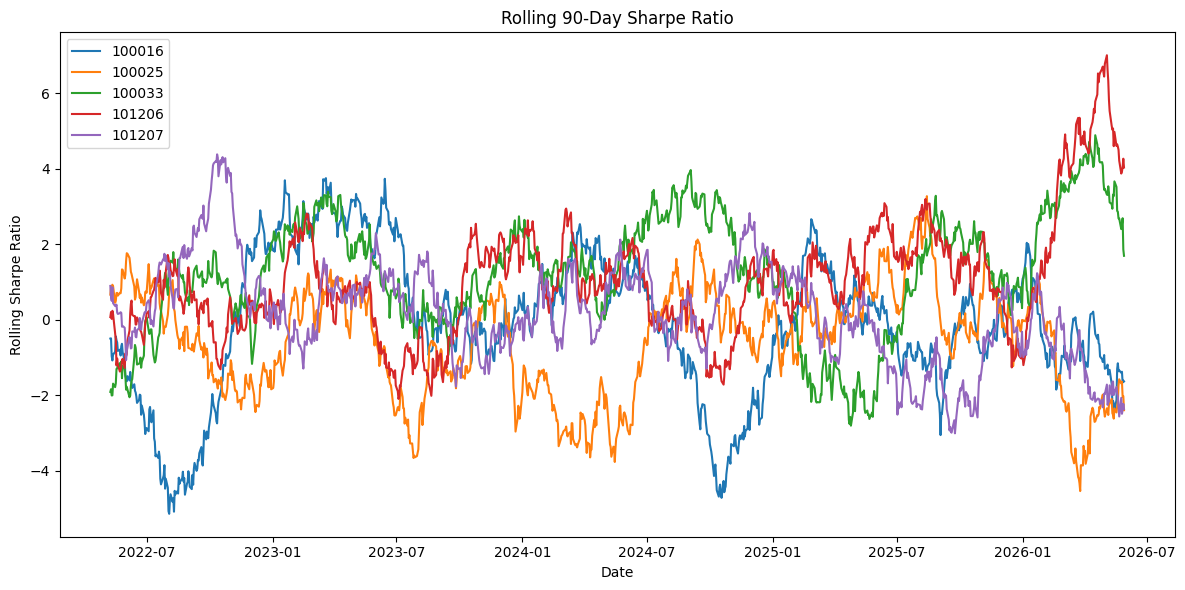

In [6]:
top5_codes = nav["amfi_code"].dropna().unique()[:5]

plt.figure(figsize=(12,6))

for code in top5_codes:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(code))

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.savefig("reports/charts/rolling_sharpe_chart.png", dpi=300)
plt.show()

In [7]:
investor["transaction_date"] = pd.to_datetime(investor["transaction_date"])

investor["cohort_year"] = investor["transaction_date"].dt.year

cohort = investor.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    investor_count=("investor_id", "nunique")
).reset_index()

cohort.to_csv("data/processed/investor_cohort_report.csv", index=False)

cohort.head()

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107739.476605,2500633252,4803
1,2025,106704.345527,1020947178,4018


In [8]:
sip_data = investor[investor["transaction_type"] == "SIP"].copy()

sip_data = sip_data.sort_values(["investor_id", "transaction_date"])

sip_summary = sip_data.groupby("investor_id").agg(
    sip_count=("transaction_date", "count"),
    first_sip=("transaction_date", "min"),
    last_sip=("transaction_date", "max")
).reset_index()

sip_summary["avg_gap_days"] = (
    (sip_summary["last_sip"] - sip_summary["first_sip"]).dt.days /
    sip_summary["sip_count"]
)

sip_summary["at_risk"] = sip_summary["avg_gap_days"] > 35

sip_summary.to_csv("data/processed/sip_continuity_report.csv", index=False)

sip_summary.head()

,investor_id,sip_count,first_sip,last_sip,avg_gap_days,at_risk
0,INV000001,2,2024-11-04,2025-01-19,38.000000,True
1,INV000002,3,2024-03-29,2025-05-17,138.000000,True
2,INV000003,2,2024-07-16,2025-03-11,119.000000,True
3,INV000004,6,2024-03-16,2025-05-17,71.166667,True
4,INV000005,3,2024-09-13,2024-10-11,9.333333,False


In [9]:
portfolio["weight_square"] = portfolio["weight_pct"] ** 2

hhi = portfolio.groupby("amfi_code")["weight_square"].sum().reset_index()

hhi.columns = ["amfi_code", "sector_hhi"]

hhi = hhi.merge(fund, on="amfi_code", how="left")

hhi.to_csv("data/processed/sector_hhi_report.csv", index=False)

hhi.head()

,amfi_code,sector_hhi,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,1395.3386,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100033,1475.9226,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,Regular,2007-06-25,NIFTY Midcap 150 TRI,1.38,1.0,500,1000,Chirag Setalvad,High,EC02
2,101206,1293.3173,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
3,101207,2007.0043,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03
4,102885,1747.0902,UTI Mutual Fund,UTI Nifty 50 Index Fund - Regular - Growth,Equity,Index,Regular,2000-03-06,NIFTY 50 TRI,1.57,0.0,500,1000,Sharwan Kumar Goyal,Moderate,EI01
